In [129]:
import numpy as np
from scipy.integrate import solve_ivp
from pyquaternion import Quaternion

np.set_printoptions(precision=3, suppress=True)

In [130]:
from typing import Optional
from jaxtyping import Float, jaxtyped
from numpy.typing import NDArray
from beartype import beartype

# Helper functions


@jaxtyped(typechecker=beartype)
def homogenous_transform(
    rotation: Optional[Float[NDArray, "3 3"]] = None,
    position: (
        Optional[Float[NDArray, "3"] | Float[NDArray, "3 1"]] | Float[NDArray, "1 3"]
    ) = None,
) -> Float[NDArray, "4 4"]:
    Transformation_matrix = np.eye(4)
    if rotation is not None:
        Transformation_matrix[0:3, 0:3] = rotation
    if position is not None:
        Transformation_matrix[0:3, 3] = position.reshape(3)

    return Transformation_matrix


@jaxtyped(typechecker=beartype)
def create_skew_matrix(
    input_vector: Float[NDArray, "3"] | Float[NDArray, "3 1"] | Float[NDArray, "1 3"],
) -> Float[NDArray, "3 3"]:

    input_vector = input_vector.reshape(
        3,
    )
    output_matrix = np.zeros((3, 3))
    output_matrix[1, 2], output_matrix[2, 1] = -input_vector[0], input_vector[0]
    output_matrix[2, 0], output_matrix[0, 2] = -input_vector[1], input_vector[1]
    output_matrix[1, 0], output_matrix[0, 1] = input_vector[2], -input_vector[2]

    return output_matrix


@jaxtyped(typechecker=beartype)
def _create_phi_rotation(
    rotation_matrix: Float[NDArray, "3 3"],
) -> Float[NDArray, "6 6"]:
    phi_rotation = np.kron(np.eye(2), rotation_matrix)

    return phi_rotation


@jaxtyped(typechecker=beartype)
def create_phi(
    position: Optional[
        Float[NDArray, "3 1"] | Float[NDArray, "3"] | Float[NDArray, "1 3"]
    ] = None,
    rotation: Optional[Float[NDArray, "3 3"]] = None,
    transpose=False,
) -> Float[NDArray, "6 6"]:
    phi = np.eye(6)
    if position is not None:
        phi[0:3, 3:6] = create_skew_matrix(position)
    if rotation is not None:
        phi = phi @ _create_phi_rotation(rotation)
    if transpose:
        phi = phi.T

    return phi

In [131]:
# Definitions in problem 1

# lengths
l_wx_b1 = np.array([[1.0], [-0.1], [0.4]])
l_yz_b2 = np.array([[1.0], [0], [0.2]])
# velocities
V_iw_in_b1 = np.array([[1.2], [0.7], [0], [0.3], [0], [2.1]])

# orientations
O_B1_I = np.array(
    [
        [1 / (2 * np.sqrt(3))],
        [1 / (2 * np.sqrt(3))],
        [1 / (2 * np.sqrt(3))],
        [np.sqrt(3) / 2],
    ]
)
O_B2_B1 = np.array(
    [
        [1 / (2 * np.sqrt(3))],
        [-1 / (2 * np.sqrt(3))],
        [1 / (2 * np.sqrt(3))],
        [np.sqrt(3) / 2],
    ]
)

# quaternions to rotation matrices - notice scalar part placement
R_B2_B1 = Quaternion(scalar=O_B2_B1[-1], vector=O_B2_B1[0:3]).rotation_matrix
R_B1_I = Quaternion(scalar=O_B1_I[-1], vector=O_B1_I[0:3]).rotation_matrix

In [132]:
# lengths in B1
l_yz_b1 = R_B2_B1 @ l_yz_b2
l_wz_b1 = l_wx_b1 + l_yz_b1

# going out from w to z - hence the transpose
phi_wz_T = create_phi(position=l_wz_b1, transpose=True)
V_iz_b1 = phi_wz_T @ V_iw_in_b1

# print(f"Viz b1 \n {V_iz_b1}")

# going from b1 to I - no transpose
phi_b1_I_T = create_phi(rotation=R_B1_I, transpose=False)
V_iz_I = phi_b1_I_T @ V_iz_b1

print(f"Viz I \n {V_iz_I}")

Viz I 
 [[ 0.567]
 [ 1.267]
 [ 0.067]
 [ 1.973]
 [-0.567]
 [-0.607]]


In [133]:
# 1.1.2
w_b2_b1_in_b1 = np.array([[3.2], [0.0], [1.2]])
# hinge map for spherical joint
H_T = np.vstack((np.eye(3), np.zeros((3, 3))))
# using formula: delta_V = H_T @ beta
delta_V_b2 = H_T @ w_b2_b1_in_b1

# series of transformations
phi_wx_T = create_phi(position=l_wx_b1, transpose=True)
phi_xx_T = create_phi(transpose=True)
phi_xy_T = create_phi(rotation=R_B2_B1, transpose=True)
phi_yz_T = create_phi(position=l_yz_b2, transpose=True)

# two lists for phi and DeltaV
phi_list = [phi_wx_T, phi_xx_T, phi_xy_T, phi_yz_T]
deltas_list = [
    np.zeros_like(delta_V_b2),
    delta_V_b2,
    np.zeros_like(delta_V_b2),
    np.zeros_like(delta_V_b2),
]

V_current = V_iw_in_b1
for phi, delta in zip(phi_list, deltas_list):
    V_next = phi @ V_current + delta
    V_current = V_next

# print(V_current)

phi_b2_I_T = create_phi(rotation=R_B1_I @ R_B2_B1, transpose=False)
V_iz_I = phi_b2_I_T @ V_current

print(V_iz_I)

[[ 3.5  ]
 [ 3.   ]
 [-0.2  ]
 [ 2.853]
 [-2.167]
 [-1.327]]


In [134]:
# 1.2.1

l_cz_c = np.array([[0.5], [1.0], [0]])
f_z_c = np.array([[0], [0], [0], [0], [0], [50]])

l_zc_c = -l_cz_c

mass = 100  # kg
inertia_c_c = np.diag((500, 50, 500))

m = np.eye(3) * mass
p_tilde = create_skew_matrix(l_zc_c)
inertia_c_x = inertia_c_c - mass * (p_tilde @ p_tilde)

spatial_M_z = np.block([[inertia_c_x, m @ p_tilde], [-m @ p_tilde, m]])


# f(x) = M(x)beta_b_dot(x) + V(x)h(x)
# f(x) - V(x)h(x) = M(x)beta_b_dot(x)
# beta_b_dot(x) = M⁻¹(f(x) - V(x)h(x))


def spatial_cross_product(
    angular_vel, linear_vel, transpose_and_negate=False
):  # TODO typehinting
    spatial_cross_vel = np.block(
        [
            [create_skew_matrix(angular_vel), np.zeros((3, 3))],
            [create_skew_matrix(linear_vel), create_skew_matrix(angular_vel)],
        ]
    )
    if transpose_and_negate:
        spatial_cross_vel = -spatial_cross_vel.T

    return spatial_cross_vel


def Equations_of_motion(spatial_inertia, forces, spatial_vel):
    spatial_vel = spatial_vel.reshape(6, 1)

    beta_b_dot = np.linalg.inv(spatial_inertia) @ (
        forces
        - spatial_cross_product(spatial_vel[0:3], spatial_vel[3:6], True)
        @ spatial_inertia
        @ spatial_vel
    )

    return beta_b_dot.reshape(
        6,
    )

In [ ]:
# 1.2.2

# IC
initial_beta_c = np.zeros((6))
initial_q = np.array([0, 0, 0, 1]).T
initial_l = l_cz_c.reshape(-1)

initial_state = np.concatenate((initial_q, initial_l, initial_beta_c))

# Simulation settings
t_start = 0
t_end = 5
t_eval = np.linspace(t_start, t_end, 100)

# Function to get the quaternion rates (see eq B.34)


def get_quaternion_rate(quaternion, angular_velocity):  # TODO typehinting
    angular_velocity = angular_velocity.reshape(
        3,
    )
    ang_vel_tilde = create_skew_matrix(angular_velocity)
    quaternion_rate = (
        0.5
        * np.block(
            [[-ang_vel_tilde, angular_velocity.reshape(3, 1)], [-angular_velocity, 0]]
        )
        @ quaternion
    )

    return quaternion_rate


def get_rotation_matrix(quarternion_scalar_last):  # TODO typehinting
    rotation_matrix = Quaternion(
        scalar=quarternion_scalar_last[-1], vector=quarternion_scalar_last[0:3]
    ).rotation_matrix

    return rotation_matrix


def get_linear_velocity(generalized_velocity, quaternion):  # TODO typehinting
    linear_velocity = get_rotation_matrix(quaternion) @ generalized_velocity

    return linear_velocity


def state_space_differentiation(state, spatial_inertia, forces):  # TODO typehinting
    quaternion = state[0:4]
    # linear_position = state[4:7] #not used
    beta = state[7:13]

    quaternion_dot = get_quaternion_rate(quaternion, beta[0:3])
    linear_velocity = get_linear_velocity(beta[3:6], quaternion)
    beta_dot = Equations_of_motion(spatial_inertia, forces, beta)

    state_diff = np.concatenate((quaternion_dot, linear_velocity, beta_dot))

    return state_diff


def integration_wrapper(time, state, spatial_inertia, forces):  # TODO typehinting
    state[0:4] = state[0:4] / np.linalg.norm(state[0:4])
    new_state = state_space_differentiation(state, spatial_inertia, forces)

    return new_state


timeseries_solution = solve_ivp(
    integration_wrapper,
    (t_start, t_end),
    initial_state,
    t_eval=t_eval,
    args=(spatial_M_z, f_z_c),
    rtol=1e-9,
    atol=1e-9,
)  # TODO typehinting

In [ ]:
# Optional prints
# print(f"Final quaternions: {timeseries_solution.y.T[-1,0:4]}")
# print(f"Final linear position: {timeseries_solution.y.T[-1,4:7]}")
# print(f"Final velocities: {timeseries_solution.y.T[-1,7:13]}")

Final quaternions: [-0.23   0.026 -0.275 -0.933]
Final linear position: [-2.293  1.051  3.63 ]
Final velocities: [ 0.02  -2.5    0.142 -0.333  0.747  1.761]


In [137]:
# This sections has been coded with the aid of ChatGPT, but the code in the cells above are hand-coded

%matplotlib widget

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Time vector and state array (states: 13 x N)
t = timeseries_solution.t  # shape (N,)
states = timeseries_solution.y.T  # shape (N, 13)

# State unpacking
quaternions = states[:, 0:4]  # q_C^I (scalar last)
pos_z_I = states[:, 4:7]  # l_I(I, z) as seen from I

# Constant body-fixed offset from C to z in frame C
l_cz_c_vec = l_cz_c.reshape(
    3,
)  # [0.5, 1.0, 0]

# Compute C position in I using: r_Iz = r_Ic + R_I_C * l_cz_c
pos_C_I = np.zeros_like(pos_z_I)

for i in range(len(t)):
    q = quaternions[i]
    R_I_C = get_rotation_matrix(q)  # maps vectors from C to I
    pos_C_I[i] = pos_z_I[i] - R_I_C @ l_cz_c_vec

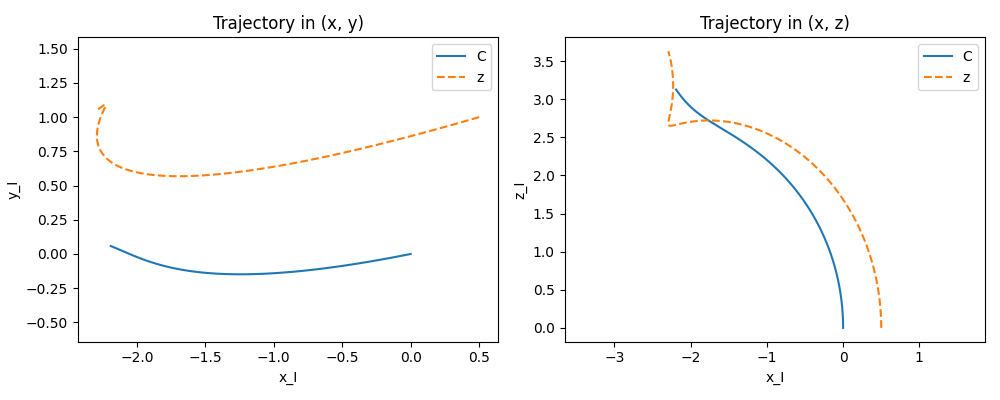

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (x, y) plot
axes[0].plot(pos_C_I[:, 0], pos_C_I[:, 1], label="C")
axes[0].plot(pos_z_I[:, 0], pos_z_I[:, 1], "--", label="z")
axes[0].set_xlabel("x_I")
axes[0].set_ylabel("y_I")
axes[0].set_title("Trajectory in (x, y)")
axes[0].axis("equal")
axes[0].legend()

# (x, z) plot
axes[1].plot(pos_C_I[:, 0], pos_C_I[:, 2], label="C")
axes[1].plot(pos_z_I[:, 0], pos_z_I[:, 2], "--", label="z")
axes[1].set_xlabel("x_I")
axes[1].set_ylabel("z_I")
axes[1].set_title("Trajectory in (x, z)")
axes[1].axis("equal")
axes[1].legend()

plt.tight_layout()
plt.show()
plt.savefig("elsearticle/images/2d_trajectories")

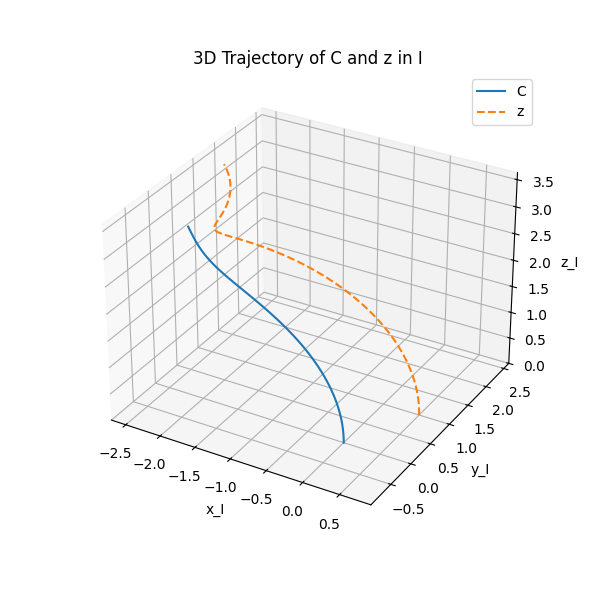

In [139]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

# Plot C and z trajectories
ax.plot(pos_C_I[:, 0], pos_C_I[:, 1], pos_C_I[:, 2], label="C")
ax.plot(pos_z_I[:, 0], pos_z_I[:, 1], pos_z_I[:, 2], "--", label="z")

ax.set_xlabel("x_I")
ax.set_ylabel("y_I")
ax.set_zlabel("z_I")
ax.set_title("3D Trajectory of C and z in I")
ax.legend()

# Make axes roughly equally scaled
xrange = pos_z_I[:, 0].max() - pos_z_I[:, 0].min()
yrange = pos_z_I[:, 1].max() - pos_z_I[:, 1].min()
zrange = pos_z_I[:, 2].max() - pos_z_I[:, 2].min()
max_range = max(xrange, yrange, zrange)
mid_x = (pos_z_I[:, 0].max() + pos_z_I[:, 0].min()) / 2
mid_y = (pos_z_I[:, 1].max() + pos_z_I[:, 1].min()) / 2
mid_z = (pos_z_I[:, 2].max() + pos_z_I[:, 2].min()) / 2
ax.set_xlim(mid_x - max_range / 2, mid_x + max_range / 2)
ax.set_ylim(mid_y - max_range / 2, mid_y + max_range / 2)
ax.set_zlim(mid_z - max_range / 2, mid_z + max_range / 2)

plt.show()
plt.savefig("elsearticle/images/3d_trajectory.png")